<a href="https://colab.research.google.com/github/jiumao2/pyDANT/blob/master/pyDANT_colab_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# pyDANT Colab Demo

Expected runtime: about 12 minutes.

pyDANT End-to-End Demo: An automated Colab walkthrough that downloads an example dataset, installs dependencies, configures parameters, executes the complete pyDANT neuron tracking pipeline, and visualizes the final results.

## Import Libraries

In [1]:
import requests
import os
from tqdm import tqdm
import numpy as np
import shutil
from IPython.display import Image, display

## Download Example Dataset

In [2]:
# Download the pyDANT example dataset:
# https://figshare.com/articles/dataset/Example_Dataset_for_pyDANT/30596303
figshare_url = r"https://figshare.com/ndownloader/files/59490728"
save_dir="/content/"

# Create a session to simulate a real browser
session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'en-US,en;q=0.5',
    'Referer': 'https://figshare.com/'
})

os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "Data_pyDANT.zip")

print("Starting download...")
print(f"Target: {save_path}\n")

with session.get(
    figshare_url,
    stream=True,
    allow_redirects=True,
    timeout=120
) as response:
    response.raise_for_status()

    # Display final URL
    print(f"Final URL: {response.url[:100]}...")

    # Get file information
    total_size = int(response.headers.get('content-length', 0))
    content_type = response.headers.get('content-type', 'unknown')

    print(f"Content-Type: {content_type}")
    print(f"Size: {total_size / (1024*1024):.2f} MB\n")

    # If HTML is returned and it's small, it's likely not the file we want
    if 'html' in content_type.lower() and total_size < 50000:
        print("❌ The response is a webpage, not a file.")
        print(f"Content preview:\n{response.text[:300]}")
        raise Exception("Failed to retrieve file download link.")

    # Start downloading
    print("Downloading...")
    with open(save_path, 'wb') as f, tqdm(
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024
    ) as bar:
        for chunk in response.iter_content(chunk_size=32768):
            if chunk:
                f.write(chunk)
                bar.update(len(chunk))

# Validation
actual_size = os.path.getsize(save_path)
print(f"\n{'='*60}")
if actual_size > 100000:
    print(f"✅ Success! File size: {actual_size/(1024*1024):.2f} MB")
else:
    print(f"❌ Failed! File is only {actual_size} bytes.")
print(f"Location: {save_path}")
print(f"{'='*60}")

Starting download...
Target: /content/Data_pyDANT.zip

Final URL: https://s3-eu-west-1.amazonaws.com/pfigshare-u-files/59490728/Data_pyDANT.zip?X-Amz-Algorithm=AWS4-H...
Content-Type: application/zip
Size: 1991.06 MB

Downloading...


100%|██████████| 1.94G/1.94G [02:22<00:00, 14.7MiB/s]


✅ Success! File size: 1991.06 MB
Location: /content/Data_pyDANT.zip


## Extract Dataset

In [3]:
# Unzip the downloaded dataset to the content directory
!unzip -q /content/Data_pyDANT.zip -d /content/

## Install pyDANT Package

In [4]:
# Install the pyDANT library
!pip install pyDANT

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 17.2 MB/s eta 0:00:00


## Import Core Modules

In [5]:
# Import necessary libraries
from pyDANT import runDANT
import hjson

## Configure User Settings & Paths

In [6]:
# Load the settings configuration
path_settings = r"/content/Data_pyDANT/settings.json"

with open(path_settings, 'r') as f:
    user_settings = hjson.load(f)

# Update paths to match the Colab environment
user_settings['path_to_data'] = r"/content/Data_pyDANT/Data/"
user_settings['output_folder'] = r"/content/Data_pyDANT/DANT_Output/"

## Run Full Pipeline & Record Execution Time

In [7]:
runDANT(user_settings)

Loading data...
The output will be saved to /content/Data_pyDANT/DANT_Output/!
18 sessions found!


100%|██████████| 3479/3479 [01:24<00:00, 40.94it/s]


Saving to /content/Data_pyDANT/DANT_Output/...
Done!


/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:192: RuntimeWarning: divide by zero encountered in arctanh
  AutoCorr_similarity_matrix = np.atanh(AutoCorr_similarity_matrix)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:201: RuntimeWarning: divide by zero encountered in arctanh
  PETH_similarity_matrix = np.atanh(PETH_similarity_matrix)


Computing similarity done!
Iteration 1 starts!
Weights:
AutoCorr   PETH
[0.30352953 0.69647047]
Iteration 2 starts!
Weights:
AutoCorr   PETH
[0.2911972 0.7088028]
Iteration 3 starts!
Weights:
AutoCorr   PETH
[0.28825973 0.71174027]
Iteration 4 starts!
Weights:
AutoCorr   PETH
[0.28784111 0.71215889]
Iteration 5 starts!
Weights:
AutoCorr   PETH
[0.28784111 0.71215889]
Convergence reached at iteration 5 (weight change < tol). Stopping early.
[Iteration 1] Found 10917 matched unit pairs.
8520 pairs of units are included for drift estimation!


...

The range of motion: [-21.7 μm ~ 17.6 μm]



Computing waveform similarity:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:129: RuntimeWarning: divide by zero encountered in arctanh
  temp = np.atanh(temp)
/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:129: RuntimeWarning: invalid value encountered in arctanh
  temp = np.atanh(temp)
Computing waveform similarity: 100%|██████████| 125/125 [00:25<00:00,  4.81it/s]
/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:192: RuntimeWarning: divide by zero encountered in arctanh
  AutoCorr_similarity_matrix = np.atanh(AutoCorr_similarity_matrix)


Computing similarity done!
Iteration 1 starts!
Weights:
Waveform   AutoCorr
[0.82913998 0.17086002]
Iteration 2 starts!
Weights:
Waveform   AutoCorr
[0.842179 0.157821]
Iteration 3 starts!
Weights:
Waveform   AutoCorr
[0.84220129 0.15779871]
Iteration 4 starts!
Weights:
Waveform   AutoCorr
[0.84220129 0.15779871]
Convergence reached at iteration 4 (weight change < tol). Stopping early.
355 clusters and 21002 pairs before removing bad units!
91 deleting steps are done!
344 clusters and 20323 pairs after removing bad units!
DANT done! Output saved to /content/Data_pyDANT/DANT_Output/Output.npz
Found 344 clusters and 20323 matches from 3479 units during 18 sessions!


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Total run time: 504.66 seconds


## Display Output Figures  
If the process completes successfully, the output figures will be saved in `/content/Data_pyDANT/DANT_Output/Figures/`.


Motion across sessions:


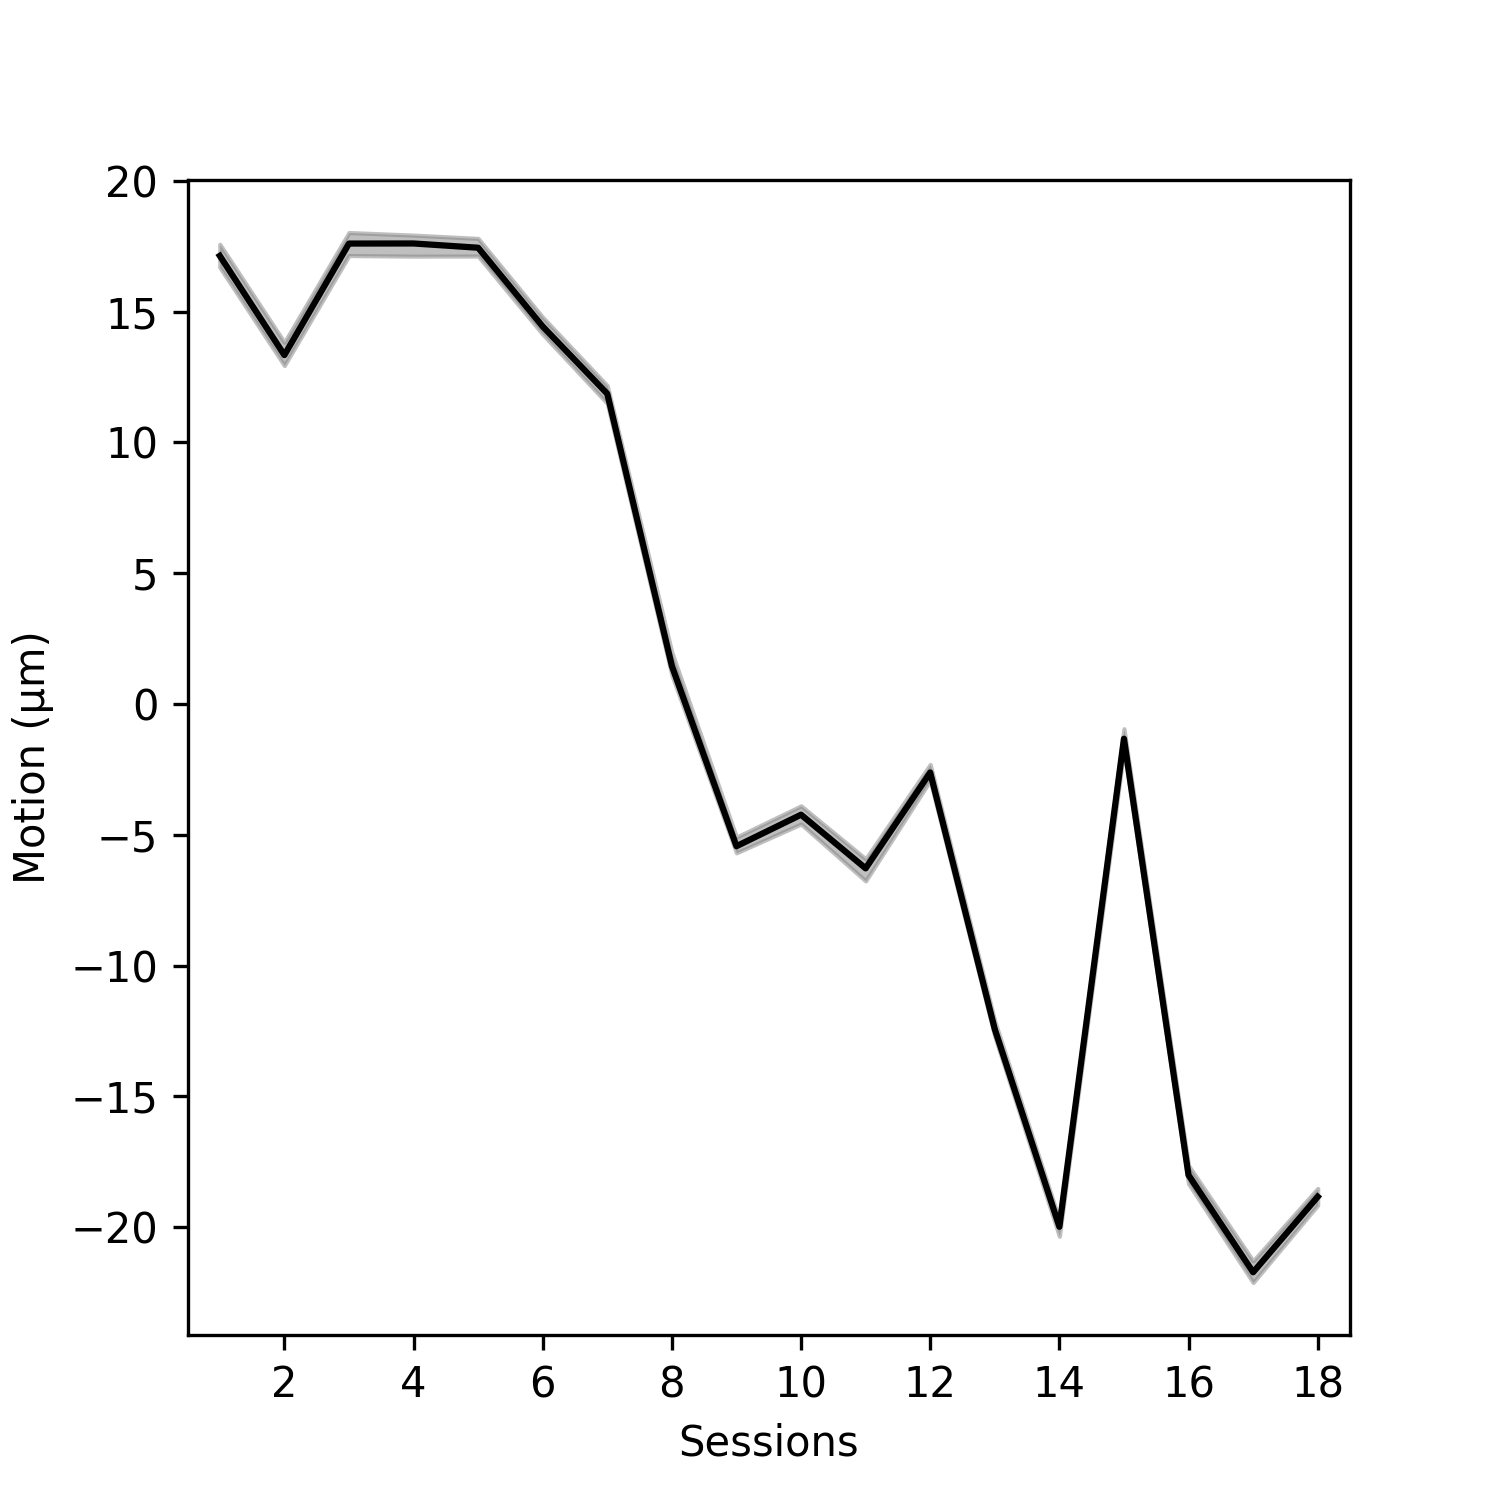


Matching probability:


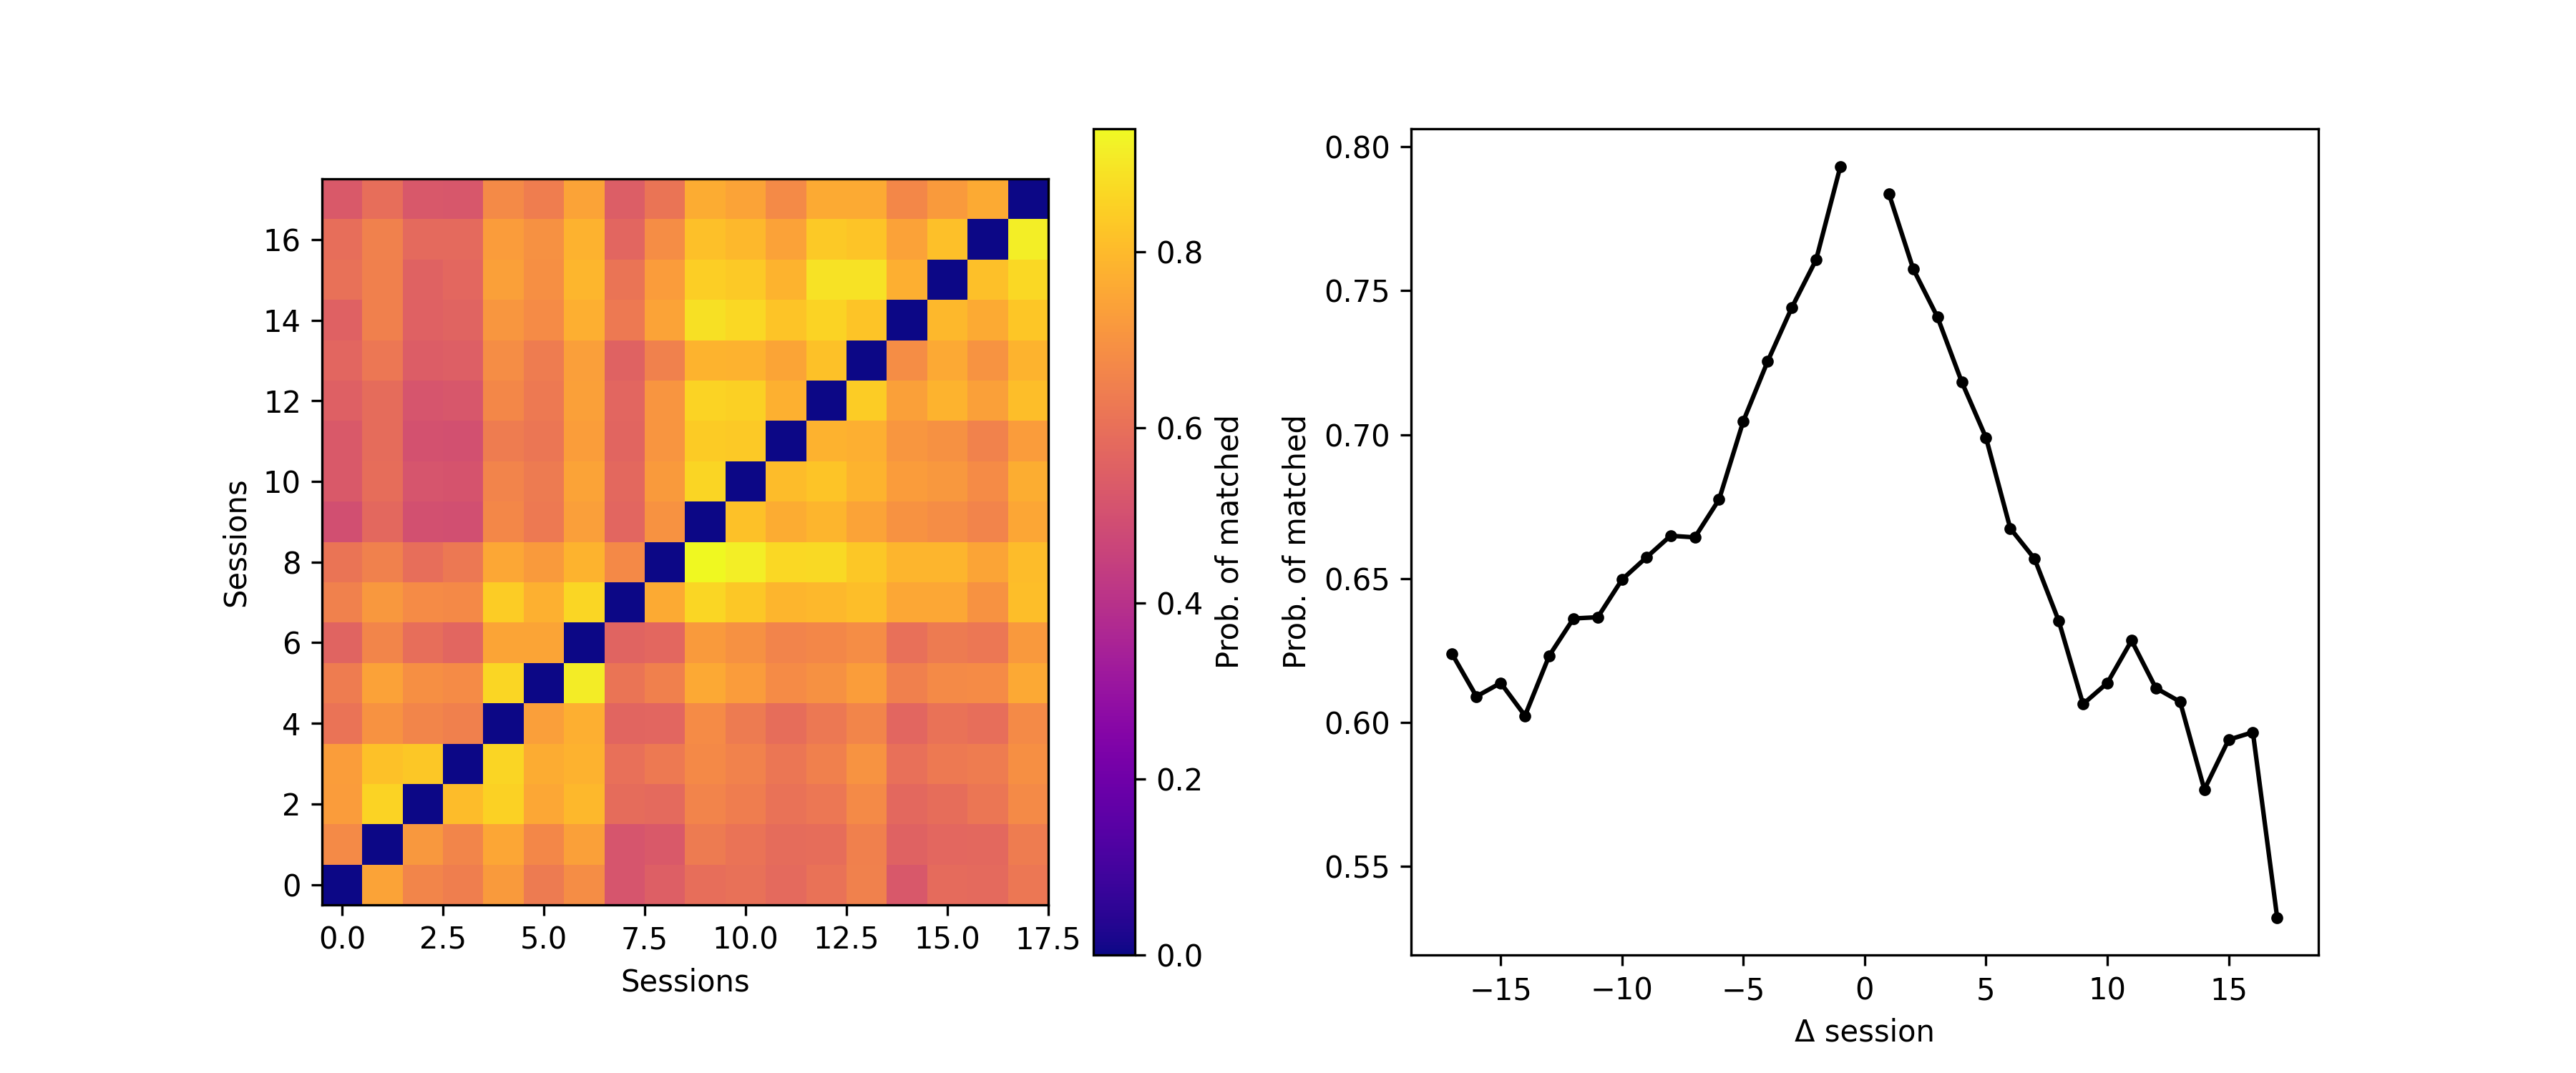

In [8]:
# Display the Motion estimation across sessions
print("Motion across sessions:")
display(Image('/content/Data_pyDANT/DANT_Output/Figures/Motion.png', width=300))

# Display the Matching probability figure
print("\nMatching probability:")
display(Image('/content/Data_pyDANT/DANT_Output/Figures/MatchedProbability.png', width=800))